In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

%matplotlib inline

In [3]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\sales_data.csv", parse_dates=["Date"])
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 53,519  |  Columns: 9


,OrderID,Date,Category,Region,Channel,UnitsSold,UnitPrice,Discount,Revenue
0,100001,2023-01-01,Electronics,North,In-Store,2,263.95,0.0,527.90
1,100024,2023-01-01,Electronics,South,In-Store,1,303.29,0.0,303.29
2,100025,2023-01-01,Beauty & Health,North,Online,2,43.53,0.0,87.06
3,100026,2023-01-01,Books & Media,South,In-Store,1,18.44,0.0,18.44
4,100027,2023-01-01,Clothing,West,In-Store,2,48.85,0.0,97.70


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53519 entries, 0 to 53518
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   OrderID    53519 non-null  int64         
 1   Date       53519 non-null  datetime64[ns]
 2   Category   53519 non-null  object        
 3   Region     53519 non-null  object        
 4   Channel    53519 non-null  object        
 5   UnitsSold  53519 non-null  int64         
 6   UnitPrice  53519 non-null  float64       
 7   Discount   53519 non-null  float64       
 8   Revenue    53519 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.7+ MB


In [5]:
df.describe(include="all")

,OrderID,Date,Category,Region,Channel,UnitsSold,UnitPrice,Discount,Revenue
count,53519.000000,53519,53519,53519,53519,53519.000000,53519.000000,53519.000000,53519.000000
unique,NaN,NaN,6,5,2,NaN,NaN,NaN,NaN
top,NaN,NaN,Clothing,North,Online,NaN,NaN,NaN,NaN
freq,NaN,NaN,13523,11794,31054,NaN,NaN,NaN,NaN
mean,126760.000000,2024-08-21 16:38:07.038248192,NaN,NaN,NaN,1.469310,93.968827,0.024899,135.207537
min,100001.000000,2023-01-01 00:00:00,NaN,NaN,NaN,1.000000,8.000000,0.000000,7.200000
25%,113380.500000,2023-11-27 00:00:00,NaN,NaN,NaN,1.000000,38.640000,0.000000,42.850000
50%,126760.000000,2024-09-19 00:00:00,NaN,NaN,NaN,1.000000,55.410000,0.000000,70.920000
75%,140139.500000,2025-05-19 00:00:00,NaN,NaN,NaN,2.000000,94.595000,0.000000,173.105000
max,153519.000000,2025-12-31 00:00:00,NaN,NaN,NaN,5.000000,441.940000,0.250000,2002.450000


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
OrderID      0
Date         0
Category     0
Region       0
Channel      0
UnitsSold    0
UnitPrice    0
Discount     0
Revenue      0
dtype: int64

Duplicate rows: 0


In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.strftime("%b")
df["Quarter"] = df["Date"].dt.quarter
df["Weekday"] = df["Date"].dt.day_name()
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

df.head()

,OrderID,Date,Category,Region,Channel,UnitsSold,UnitPrice,Discount,Revenue,Year,Month,MonthName,Quarter,Weekday,YearMonth
0,100001,2023-01-01,Electronics,North,In-Store,2,263.95,0.0,527.90,2023,1,Jan,1,Sunday,2023-01
1,100024,2023-01-01,Electronics,South,In-Store,1,303.29,0.0,303.29,2023,1,Jan,1,Sunday,2023-01
2,100025,2023-01-01,Beauty & Health,North,Online,2,43.53,0.0,87.06,2023,1,Jan,1,Sunday,2023-01
3,100026,2023-01-01,Books & Media,South,In-Store,1,18.44,0.0,18.44,2023,1,Jan,1,Sunday,2023-01
4,100027,2023-01-01,Clothing,West,In-Store,2,48.85,0.0,97.70,2023,1,Jan,1,Sunday,2023-01


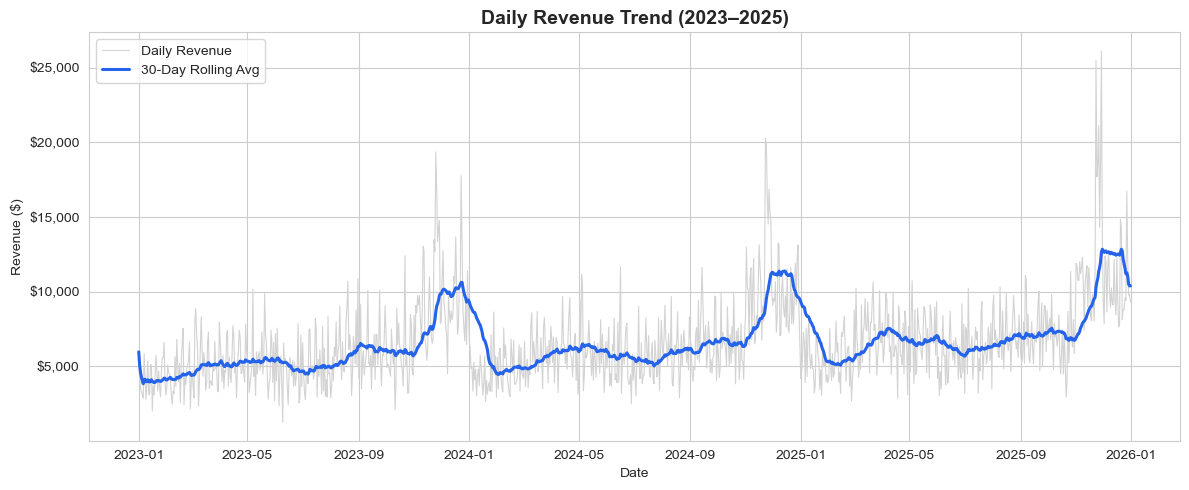

In [8]:
daily = df.groupby("Date", as_index=False)["Revenue"].sum()
daily["Rolling30"] = daily["Revenue"].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots()
ax.plot(daily["Date"], daily["Revenue"], color="lightgray", linewidth=0.8, label="Daily Revenue")
ax.plot(daily["Date"], daily["Rolling30"], color="#2563eb", linewidth=2.2, label="30-Day Rolling Avg")
ax.set_title("Daily Revenue Trend (2023–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

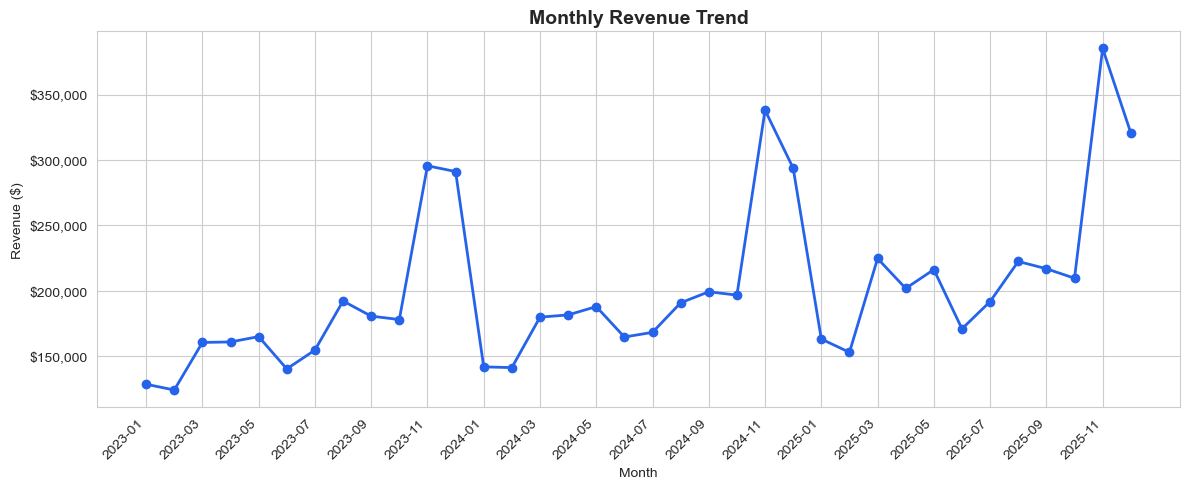

In [9]:
monthly = df.groupby("YearMonth", as_index=False)["Revenue"].sum()

fig, ax = plt.subplots()
ax.plot(monthly["YearMonth"], monthly["Revenue"], marker="o", color="#2563eb", linewidth=2)
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

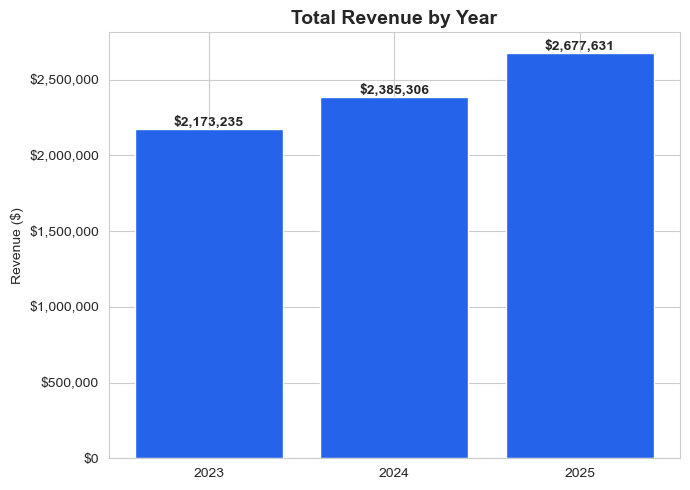

,Year,Revenue
0,2023,2173234.90
1,2024,2385306.35
2,2025,2677630.90


In [10]:
yearly = df.groupby("Year", as_index=False)["Revenue"].sum()

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(yearly["Year"].astype(str), yearly["Revenue"], color="#2563eb")
ax.set_title("Total Revenue by Year")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for b in bars:
    ax.annotate(f"${b.get_height():,.0f}", (b.get_x()+b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

yearly

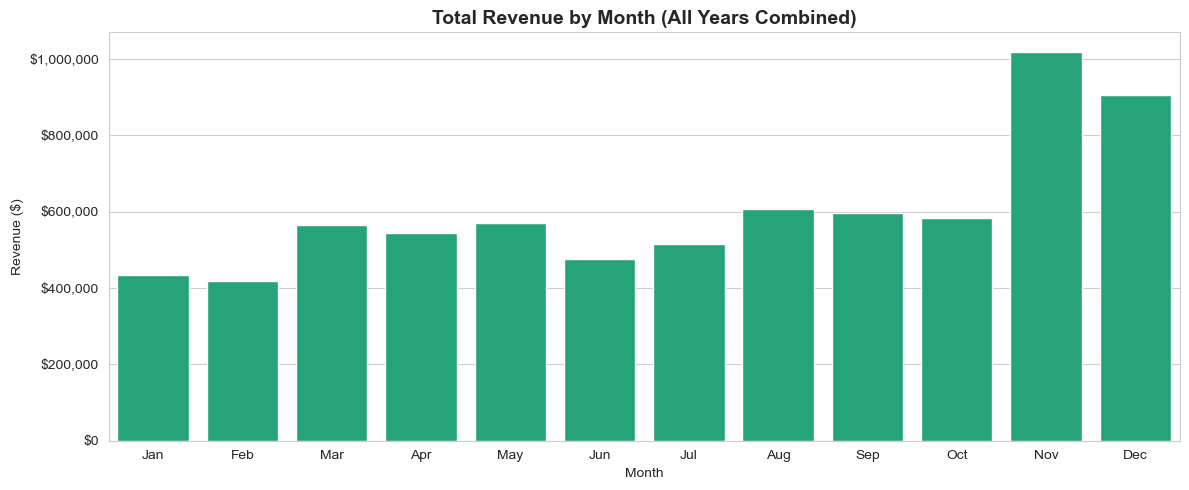

In [11]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_avg = df.groupby("MonthName")["Revenue"].sum().reindex(month_order)

fig, ax = plt.subplots()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, color="#10b981", ax=ax)
ax.set_title("Total Revenue by Month (All Years Combined)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

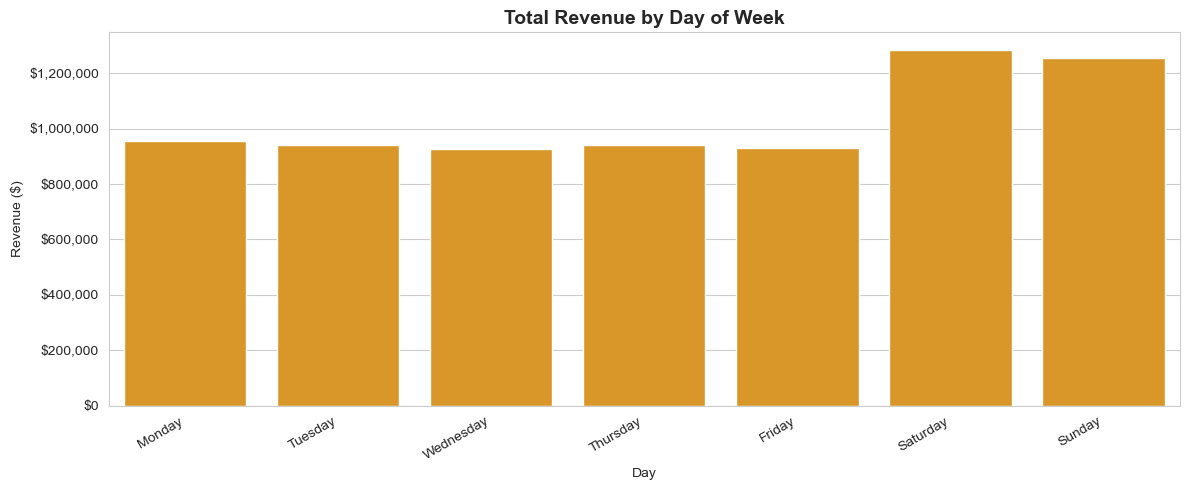

In [12]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_avg = df.groupby("Weekday")["Revenue"].sum().reindex(day_order)

fig, ax = plt.subplots()
sns.barplot(x=weekday_avg.index, y=weekday_avg.values, color="#f59e0b", ax=ax)
ax.set_title("Total Revenue by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

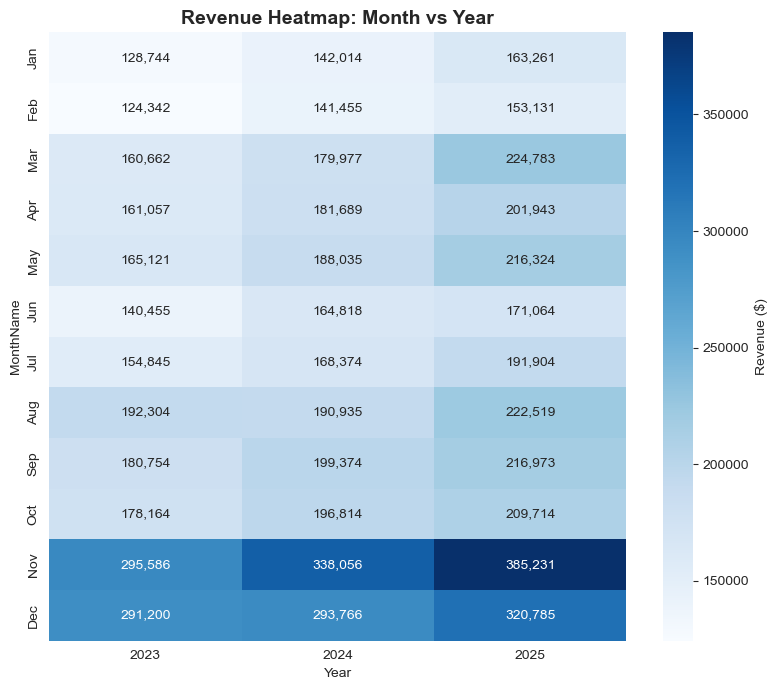

In [13]:
pivot = df.pivot_table(index="MonthName", columns="Year", values="Revenue", aggfunc="sum")
pivot = pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="Blues", ax=ax, cbar_kws={"label": "Revenue ($)"})
ax.set_title("Revenue Heatmap: Month vs Year")
plt.tight_layout()
plt.show()

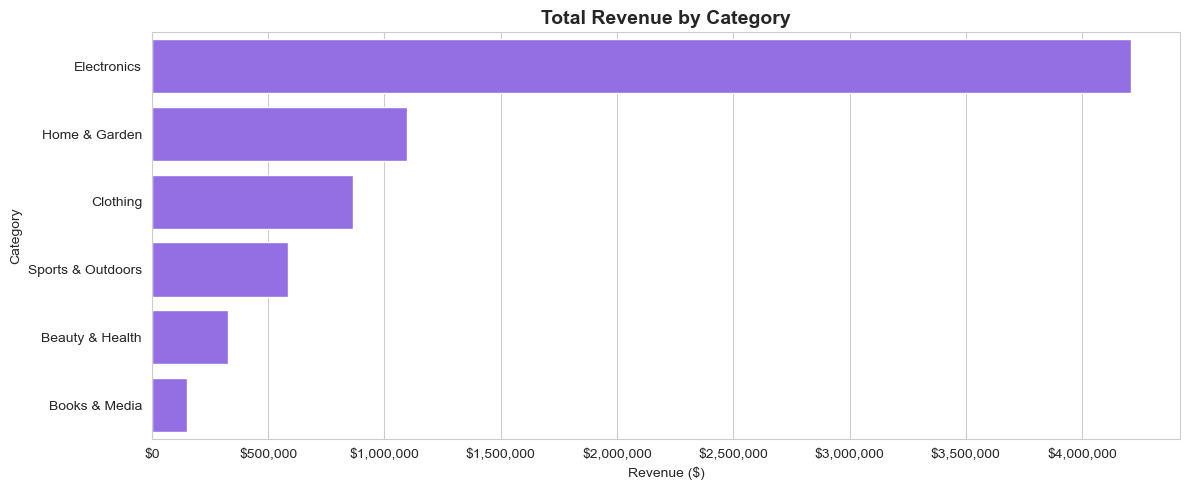

In [14]:
cat_rev = df.groupby("Category", as_index=False)["Revenue"].sum().sort_values("Revenue", ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=cat_rev, x="Revenue", y="Category", color="#8b5cf6", ax=ax)
ax.set_title("Total Revenue by Category")
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

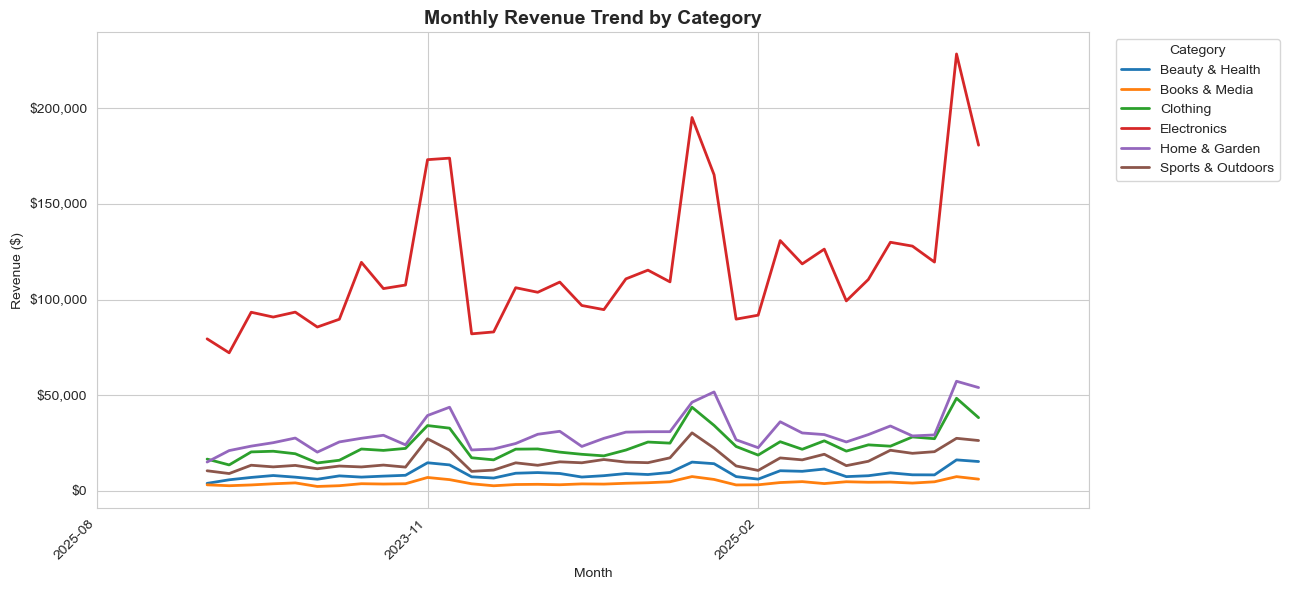

In [15]:
cat_monthly = df.groupby(["YearMonth", "Category"])["Revenue"].sum().reset_index()
cat_pivot = cat_monthly.pivot(index="YearMonth", columns="Category", values="Revenue")

fig, ax = plt.subplots(figsize=(13,6))
cat_pivot.plot(ax=ax, linewidth=2)
ax.set_title("Monthly Revenue Trend by Category")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticks(ax.get_xticks()[::3])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

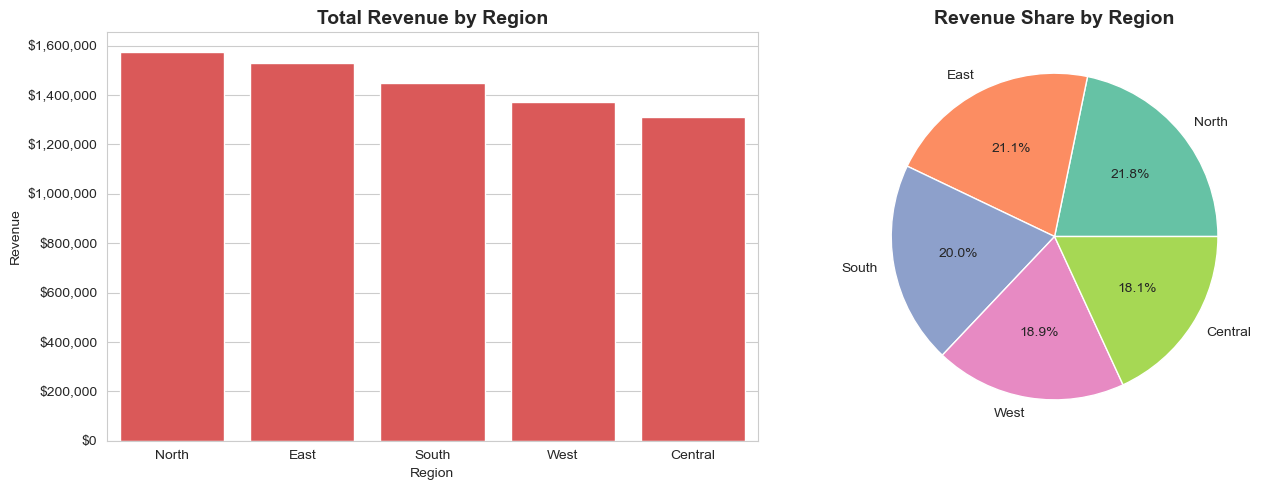

In [16]:
region_rev = df.groupby("Region", as_index=False)["Revenue"].sum().sort_values("Revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=region_rev, x="Region", y="Revenue", color="#ef4444", ax=axes[0])
axes[0].set_title("Total Revenue by Region")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[1].pie(region_rev["Revenue"], labels=region_rev["Region"], autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[1].set_title("Revenue Share by Region")

plt.tight_layout()
plt.show()

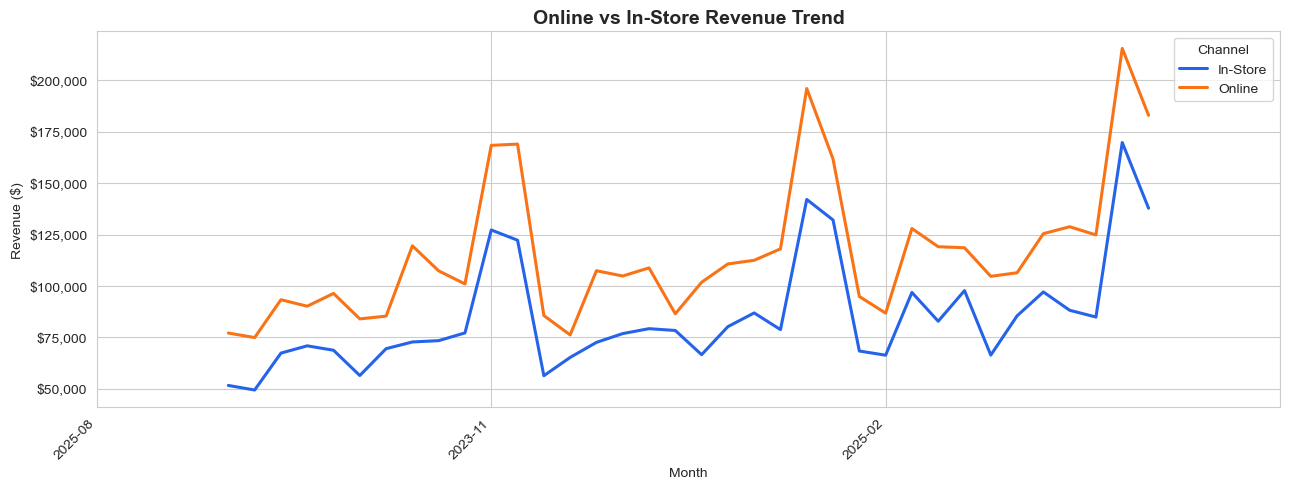

Channel share of total revenue:
Channel
In-Store    42.3%
Online      57.7%
Name: Revenue, dtype: object


In [17]:
channel_monthly = df.groupby(["YearMonth", "Channel"])["Revenue"].sum().reset_index()
channel_pivot = channel_monthly.pivot(index="YearMonth", columns="Channel", values="Revenue")

fig, ax = plt.subplots(figsize=(13,5))
channel_pivot.plot(ax=ax, linewidth=2.2, color=["#2563eb", "#f97316"])
ax.set_title("Online vs In-Store Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xticks(ax.get_xticks()[::3])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

channel_totals = df.groupby("Channel")["Revenue"].sum()
print("Channel share of total revenue:")
print((channel_totals / channel_totals.sum() * 100).round(1).astype(str) + "%")

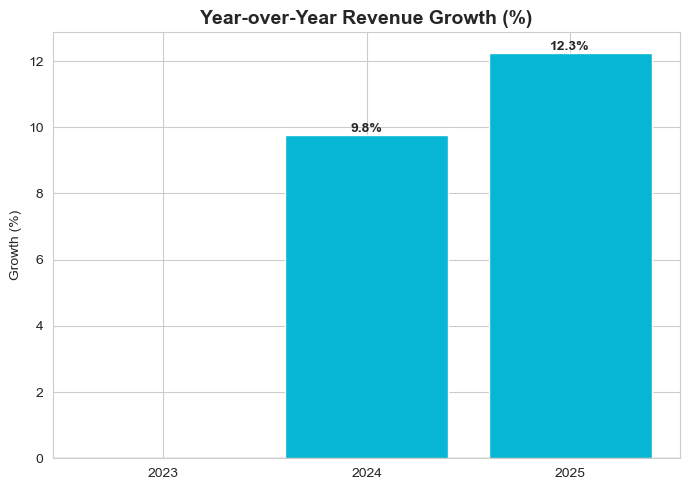

,Year,Revenue,YoY_Growth_%
0,2023,2173234.90,NaN
1,2024,2385306.35,9.758331
2,2025,2677630.90,12.255220


In [18]:
yearly["YoY_Growth_%"] = yearly["Revenue"].pct_change() * 100

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(yearly["Year"].astype(str), yearly["YoY_Growth_%"].fillna(0), color="#06b6d4")
ax.set_title("Year-over-Year Revenue Growth (%)")
ax.set_ylabel("Growth (%)")
ax.axhline(0, color="black", linewidth=0.8)
for b in bars:
    h = b.get_height()
    if h != 0:
        ax.annotate(f"{h:.1f}%", (b.get_x()+b.get_width()/2, h), ha="center",
                    va="bottom" if h>=0 else "top", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

yearly

In [19]:
best_month = monthly.loc[monthly["Revenue"].idxmax()]
best_category = cat_rev.iloc[0]
best_region = region_rev.iloc[0]
total_revenue = df["Revenue"].sum()
total_orders = df["OrderID"].nunique()
avg_order_value = total_revenue / total_orders

print("📊 SALES TREND — KEY INSIGHTS")
print("=" * 45)
print(f"Total Revenue (2023-2025):  ${total_revenue:,.0f}")
print(f"Total Orders:                {total_orders:,}")
print(f"Average Order Value:         ${avg_order_value:,.2f}")
print(f"Best Performing Month:       {best_month['YearMonth']} (${best_month['Revenue']:,.0f})")
print(f"Top Category:                {best_category['Category']} (${best_category['Revenue']:,.0f})")
print(f"Top Region:                  {best_region['Region']} (${best_region['Revenue']:,.0f})")
print(f"Revenue Growth {yearly['Year'].iloc[0]}->{yearly['Year'].iloc[-1]}: "
      f"{((yearly['Revenue'].iloc[-1]/yearly['Revenue'].iloc[0])-1)*100:.1f}%")

📊 SALES TREND — KEY INSIGHTS
Total Revenue (2023-2025):  $7,236,172
Total Orders:                53,519
Average Order Value:         $135.21
Best Performing Month:       2025-11 ($385,231)
Top Category:                Electronics ($4,210,480)
Top Region:                  North ($1,575,002)
Revenue Growth 2023->2025: 23.2%
